# 🧠 Supervised Contrastive Learning (SupCon)

**Part III · The SupCon Pipeline (Scalability & Transfer)**

---

## 👤 Instructor

**Ing. Jesús Alan Hernández Galván**

📫 [alanhernandezgalvan@icloud.com](mailto:alanhernandezgalvan@icloud.com)
🌐 [https://unlikeghost.github.io/](https://unlikeghost.github.io/)

---

## 🗺️ Progreso del curso

1. CNN: The Feature Extractor ✅
2. Embedding Architectures & Similarity Learning ✅
3. **The SupCon Pipeline (Scalability & Transfer) 🚀**

---

## 🎯 Objetivo del módulo

Escalar Supervised Contrastive Learning hacia un pipeline robusto, optimizando el entrenamiento, la organización del espacio latente y su capacidad de transferencia a nuevas tareas.


In [1]:
import sys

def check_environment():
    if 'google.colab' in sys.modules:
        print("Entorno: Google Colab ☁️")

        from IPython import get_ipython
        ipython = get_ipython()
        if ipython:
            print("Instalando dependencias necesarias...")
            ipython.run_line_magic('pip', 'install --upgrade umap-learn numba')

        return "colab"
    else:
        print("Entorno: Local / Jupyter Notebook 💻")
        return "local"

env = check_environment()

Entorno: Local / Jupyter Notebook 💻


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import os
import logging

os.environ["TORCH_LOGS"] = "-all"
logging.getLogger("torch._inductor").setLevel(logging.ERROR)

In [4]:
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(project_root, "data")
models_path = os.path.join(project_root, "models")

## Librerias

In [5]:
import umap
import torch
import random
import torchvision

import numpy as np
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from torchsummary import summary
from sklearn.metrics import confusion_matrix

In [6]:
from src.models import MiniConvNetEncoder, MiniConvNetLinearProbe
from src.plot_data import show_batch, show_features, plot_latent_space_3d, plot_latent_space_2d
from src.datasets import ClassificationDataset

## 🔒 Semilla para reproducibilidad

In [7]:
seed: int = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

## ⚡ Optimización de Aceleración por Hardware (CUDA/cuDNN)

### 🚀 Verificar uso de GPU (si está disponible)

In [8]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
    )
print(f"Status: System ready on {device}")

Status: System ready on cuda


In [9]:
if device == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.allow_tf32 = True

## 🧪 Implementación

In [10]:
batch_size: int = 512

classes: tuple = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(size=(32, 32), scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

In [11]:
base_train = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
)

base_test = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
)

In [12]:
test_data = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
)

full_train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
)

# Definimos los tamaños (80% train, 20% val)
train_size = int(len(full_train_dataset) * .8)
val_size = int(len(full_train_dataset) - train_size)

train_size, val_size, len(test_data)

(40000, 10000, 10000)

In [13]:
train_data, val_data = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

In [14]:
train_dataset = ClassificationDataset(
    dataset=train_data,
    transform=train_transform
)
val_dataset = ClassificationDataset(
    dataset=val_data,
    transform=val_transform
)

test_dataset  = ClassificationDataset(
    dataset=test_data,
    transform=val_transform
)

In [15]:
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

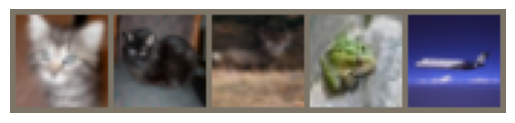

In [16]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images[:5]

show_batch(
    torchvision.utils.make_grid(images),
)

### 🧠 Embedding-Based Classification

### ⚙️ Proceso de entrenamiento

In [17]:
num_epochs: int = 30
criterion = nn.CrossEntropyLoss().to(device)

#### 🧊 Experimento A: Linear Probing (Backbone Congelado)

In [18]:
num_epochs: int = 30
criterion = nn.CrossEntropyLoss().to(device)

encoder = MiniConvNetEncoder(output_dim=256).to(device)
encoder.load_state_dict(
    torch.load(os.path.join(models_path, "MiniConv_siamese.pth"))
)

classifier_lp = MiniConvNetLinearProbe(encoder=encoder).to(device)

for param in classifier_lp.encoder.parameters():
    param.requires_grad = False

optimizer_lp = optim.Adam(
    filter(lambda p: p.requires_grad, classifier_lp.parameters()),
    lr=1e-3
)

scheduler_lp = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_lp,
    T_max=num_epochs * len(train_loader),
    eta_min=1e-6
)

In [19]:
summary(classifier_lp, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,496
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
         MaxPool2d-8             [-1, 64, 8, 8]               0
            Linear-9                  [-1, 512]       2,097,664
      BatchNorm1d-10                  [-1, 512]           1,024
             ReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                  [-1, 256]         131,328
MiniConvNetEncoder-14                  

In [20]:
train_loss_lp, val_loss_lp = [], []
train_acc_lp, val_acc_lp = [], []

for epoch in range(num_epochs):
    # --- FASE DE ENTRENAMIENTO ---
    classifier_lp.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_lp.zero_grad()
        outputs = classifier_lp(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_lp.step()
        scheduler_lp.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # --- FASE DE VALIDACIÓN ---
    classifier_lp.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = classifier_lp(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Métricas finales de la época
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    train_loss_lp.append(epoch_loss)
    train_acc_lp.append(epoch_acc)
    val_loss_lp.append(epoch_val_loss)
    val_acc_lp.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}")

Epoch [1/30] Train Loss: 2.1164 - Acc: 0.5419 | Val Loss: 1.9552 - Acc: 0.7101
Epoch [2/30] Train Loss: 1.8032 - Acc: 0.7405 | Val Loss: 1.6951 - Acc: 0.7204
Epoch [3/30] Train Loss: 1.5682 - Acc: 0.7561 | Val Loss: 1.5021 - Acc: 0.7256
Epoch [4/30] Train Loss: 1.3932 - Acc: 0.7604 | Val Loss: 1.3589 - Acc: 0.7228
Epoch [5/30] Train Loss: 1.2617 - Acc: 0.7673 | Val Loss: 1.2508 - Acc: 0.7277
Epoch [6/30] Train Loss: 1.1616 - Acc: 0.7671 | Val Loss: 1.1694 - Acc: 0.7293
Epoch [7/30] Train Loss: 1.0826 - Acc: 0.7666 | Val Loss: 1.1087 - Acc: 0.7316
Epoch [8/30] Train Loss: 1.0238 - Acc: 0.7720 | Val Loss: 1.0620 - Acc: 0.7296
Epoch [9/30] Train Loss: 0.9759 - Acc: 0.7700 | Val Loss: 1.0211 - Acc: 0.7329
Epoch [10/30] Train Loss: 0.9381 - Acc: 0.7707 | Val Loss: 0.9880 - Acc: 0.7354
Epoch [11/30] Train Loss: 0.9025 - Acc: 0.7720 | Val Loss: 0.9655 - Acc: 0.7317
Epoch [12/30] Train Loss: 0.8770 - Acc: 0.7751 | Val Loss: 0.9457 - Acc: 0.7302
Epoch [13/30] Train Loss: 0.8566 - Acc: 0.7734 | 

In [21]:
torch.save(
    classifier_lp.state_dict(),
    os.path.join(models_path, "MiniConv_lp.pth")
)

#### 🛡️ Experimento B: Fine-tuning (Ajuste Fino Global)

In [22]:
num_epochs = 30
criterion = nn.CrossEntropyLoss().to(device)

encoder = MiniConvNetEncoder(output_dim=256).to(device)
encoder.load_state_dict(torch.load(
    os.path.join(models_path, "MiniConv_siamese.pth"))
)

classifier_ft = MiniConvNetLinearProbe(encoder=encoder).to(device)

for param in classifier_ft.encoder.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam([
    {"params": classifier_ft.encoder.parameters(), "lr": 1e-5},
    {"params": classifier_ft.classifier.parameters(), "lr": 1e-3},
])

scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft,
    T_max=num_epochs,
    eta_min=1e-6
)

In [23]:
summary(classifier_ft, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,496
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
         MaxPool2d-8             [-1, 64, 8, 8]               0
            Linear-9                  [-1, 512]       2,097,664
      BatchNorm1d-10                  [-1, 512]           1,024
             ReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                  [-1, 256]         131,328
MiniConvNetEncoder-14                  

In [24]:
train_loss_ft, val_loss_ft = [], []
train_acc_ft, val_acc_ft = [], []

for epoch in range(num_epochs):
    # --- FASE DE ENTRENAMIENTO ---
    classifier_ft.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad()
        outputs = classifier_ft(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_ft.step()
        scheduler_ft.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # --- FASE DE VALIDACIÓN ---
    classifier_ft.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = classifier_ft(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Métricas finales de la época
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    train_loss_ft.append(epoch_loss)
    train_acc_ft.append(epoch_acc)
    val_loss_ft.append(epoch_val_loss)
    val_acc_ft.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f}")

Epoch [1/30] Train Loss: 2.1910 - Acc: 0.3906 | Val Loss: 2.0726 - Acc: 0.5363
Epoch [2/30] Train Loss: 1.9807 - Acc: 0.6233 | Val Loss: 1.9048 - Acc: 0.6515
Epoch [3/30] Train Loss: 1.7727 - Acc: 0.7238 | Val Loss: 1.6940 - Acc: 0.6898
Epoch [4/30] Train Loss: 1.5626 - Acc: 0.7400 | Val Loss: 1.4801 - Acc: 0.7041
Epoch [5/30] Train Loss: 1.3827 - Acc: 0.7460 | Val Loss: 1.3552 - Acc: 0.7171
Epoch [6/30] Train Loss: 1.2364 - Acc: 0.7478 | Val Loss: 1.2281 - Acc: 0.7184
Epoch [7/30] Train Loss: 1.1098 - Acc: 0.7541 | Val Loss: 1.1143 - Acc: 0.7198
Epoch [8/30] Train Loss: 1.0107 - Acc: 0.7559 | Val Loss: 1.0518 - Acc: 0.7226
Epoch [9/30] Train Loss: 0.9376 - Acc: 0.7605 | Val Loss: 0.9991 - Acc: 0.7262
Epoch [10/30] Train Loss: 0.8716 - Acc: 0.7616 | Val Loss: 0.9423 - Acc: 0.7307
Epoch [11/30] Train Loss: 0.8233 - Acc: 0.7680 | Val Loss: 0.9068 - Acc: 0.7328
Epoch [12/30] Train Loss: 0.7859 - Acc: 0.7727 | Val Loss: 0.8831 - Acc: 0.7327
Epoch [13/30] Train Loss: 0.7555 - Acc: 0.7712 | 

In [25]:
torch.save(
    classifier_ft.state_dict(),
    os.path.join(models_path, "MiniConv_ft.pth")
)

#### 🔍 Experimento C: Clasificación No Paramétrica sobre Embeddings

In [26]:
def get_embeddings(model, loader, device):
    model.eval()
    all_embeddings, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embeddings = model(images)  # L2-normalizado
            all_embeddings.append(embeddings.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_embeddings), np.concatenate(all_labels)

train_embeddings, train_labels = get_embeddings(encoder, train_loader, device)
test_embeddings, test_labels   = get_embeddings(encoder, test_loader, device)

In [27]:
svm = SVC(
    kernel='rbf',
    gamma='scale',
    random_state=seed
)

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean',
    weights='distance',
    n_jobs=-1
)

In [28]:
svm.fit(train_embeddings, train_labels)
svm.score(test_embeddings, test_labels)

0.7657

In [29]:
knn.fit(train_embeddings, train_labels)
knn.score(test_embeddings, test_labels)

0.747

### 📊 Métricas de entrenamiento y validación

#### 📊 Entrenamiento

##### Backbone Congelado

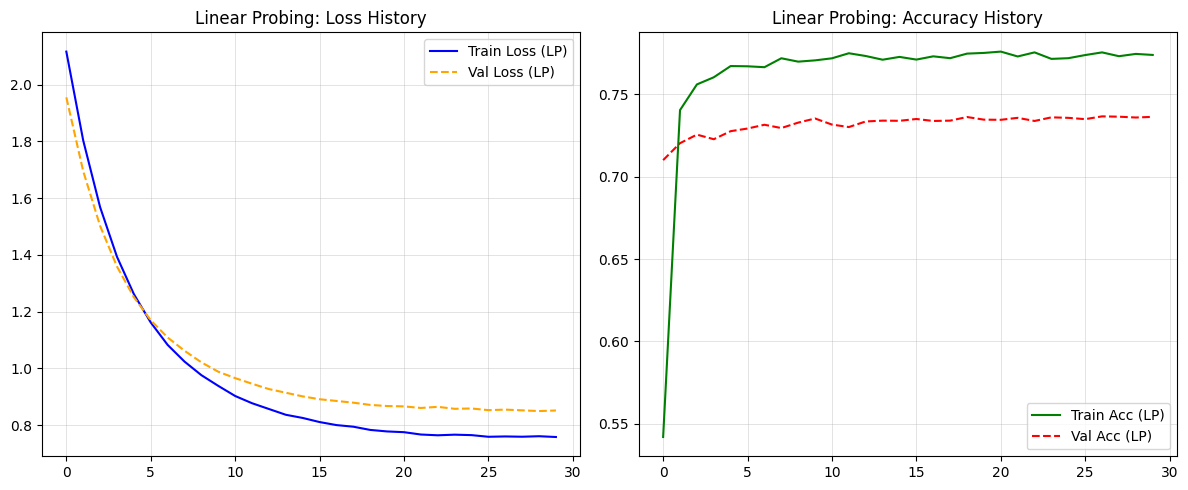

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Loss
axs[0].plot(train_loss_lp, label='Train Loss (LP)', color='blue')
axs[0].plot(val_loss_lp, label='Val Loss (LP)', color='orange', linestyle='--')
axs[0].set_title('Linear Probing: Loss History')
axs[0].legend()
axs[0].grid(True)

# Accuracy
axs[1].plot(train_acc_lp, label='Train Acc (LP)', color='green')
axs[1].plot(val_acc_lp, label='Val Acc (LP)', color='red', linestyle='--')
axs[1].set_title('Linear Probing: Accuracy History')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

##### Fine-tuning

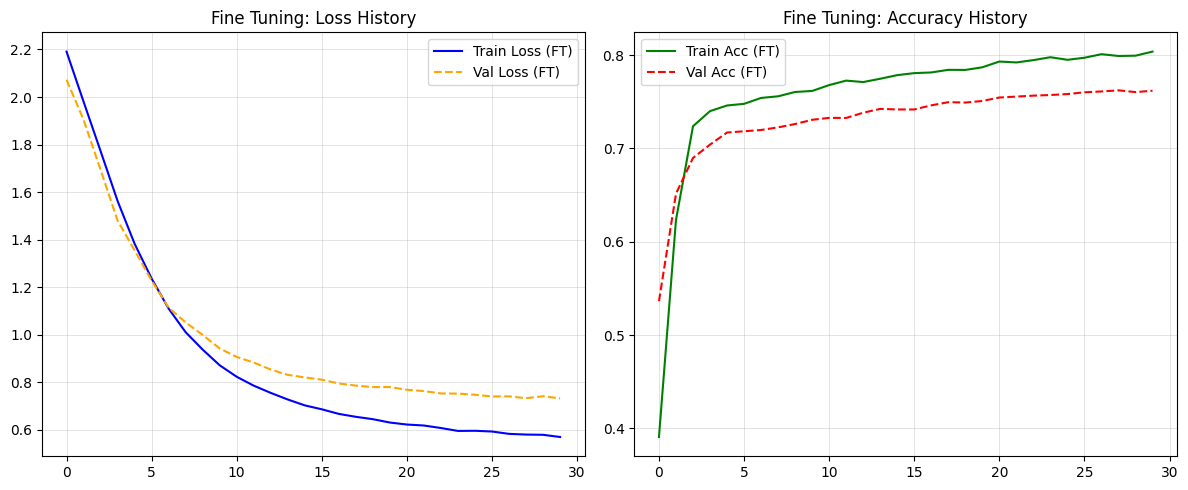

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Loss
axs[0].plot(train_loss_ft, label='Train Loss (FT)', color='blue')
axs[0].plot(val_loss_ft, label='Val Loss (FT)', color='orange', linestyle='--')
axs[0].set_title('Fine Tuning: Loss History')
axs[0].legend()
axs[0].grid(True)

# Accuracy
axs[1].plot(train_acc_ft, label='Train Acc (FT)', color='green')
axs[1].plot(val_acc_ft, label='Val Acc (FT)', color='red', linestyle='--')
axs[1].set_title('Fine Tuning: Accuracy History')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 📊 Validación

##### Backbone Congelado

In [32]:
classifier_lp.eval() # Nos aseguramos de que esté en modo evaluación

all_preds_lp = []
all_labels_lp = []

# 1. Pasamos TODAS las imágenes de test por el modelo sin calcular gradientes
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = classifier_lp(images)

        # torch.max nos devuelve el valor máximo y su ÍNDICE (la clase predicha)
        _, predicted = torch.max(outputs, 1)

        # Guardamos las predicciones y las etiquetas reales en la CPU
        all_preds_lp.extend(predicted.cpu().numpy())
        all_labels_lp.extend(labels.numpy())

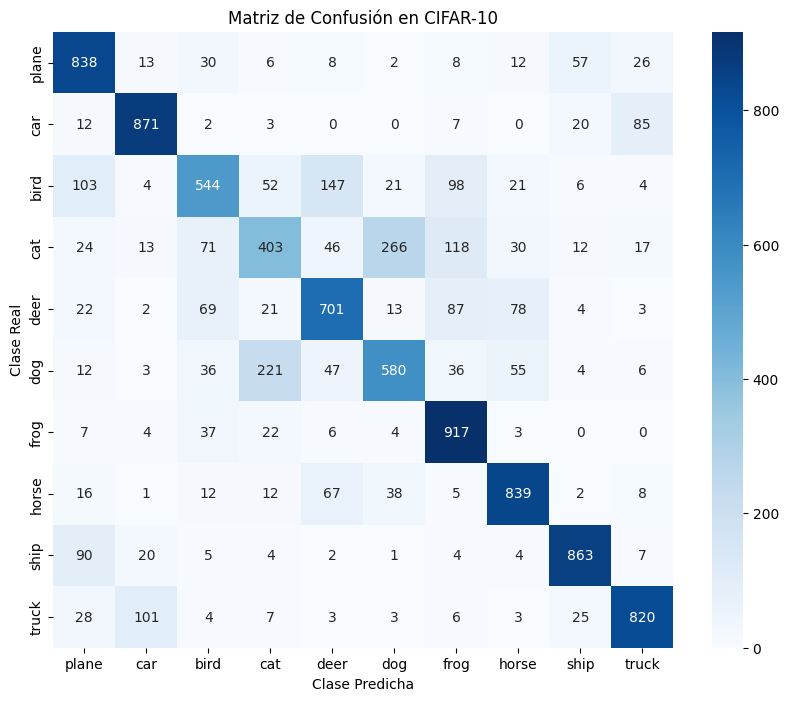

In [33]:
# 2. Creamos la matriz numérica con sklearn
cm = confusion_matrix(all_labels_lp, all_preds_lp)

# 3. Dibujamos la matriz
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión en CIFAR-10')
plt.show()

##### Fine-tuning

In [34]:
classifier_ft.eval() # Nos aseguramos de que esté en modo evaluación

all_preds_ft = []
all_labels_ft = []

# 1. Pasamos TODAS las imágenes de test por el modelo sin calcular gradientes
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = classifier_ft(images)

        # torch.max nos devuelve el valor máximo y su ÍNDICE (la clase predicha)
        _, predicted = torch.max(outputs, 1)

        # Guardamos las predicciones y las etiquetas reales en la CPU
        all_preds_ft.extend(predicted.cpu().numpy())
        all_labels_ft.extend(labels.numpy())

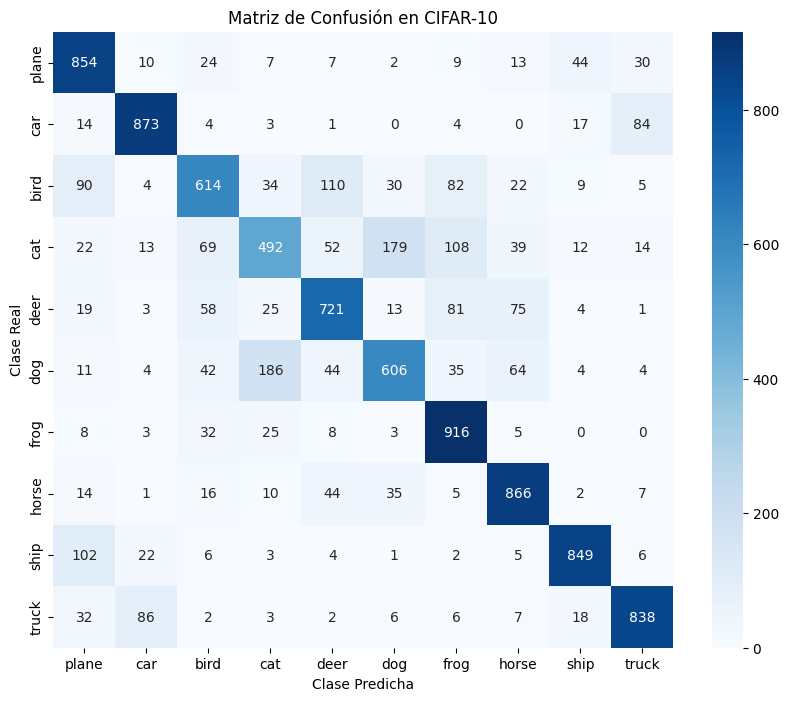

In [35]:
# 2. Creamos la matriz numérica con sklearn
cm = confusion_matrix(all_labels_ft, all_preds_ft)

# 3. Dibujamos la matriz
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión en CIFAR-10')
plt.show()

##### SVM

In [36]:
all_preds_svm = svm.predict(test_embeddings)
all_labels_svm = test_labels

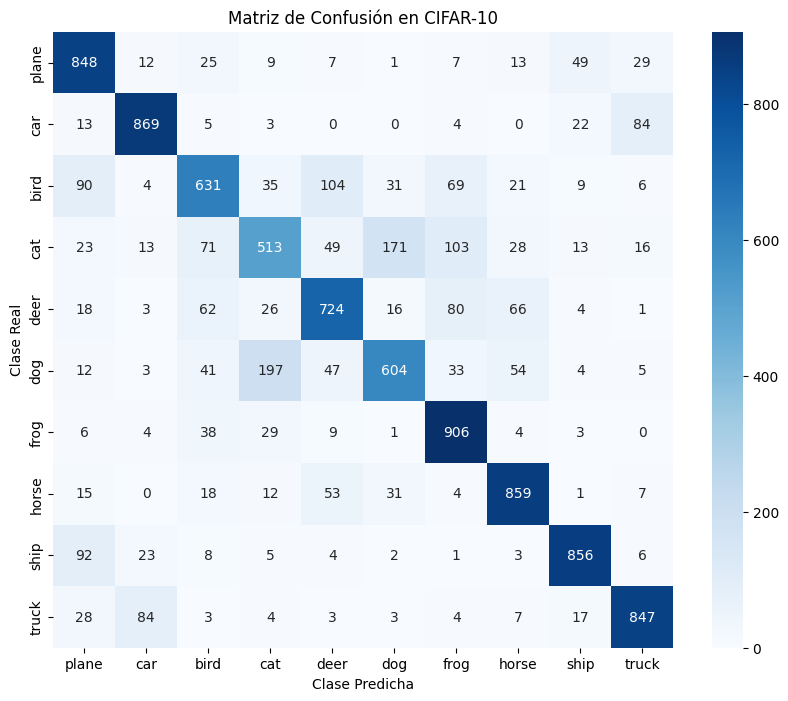

In [37]:
cm = confusion_matrix(all_labels_svm, all_preds_svm)

# 3. Dibujamos la matriz
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión en CIFAR-10')
plt.show()

##### KNN

In [38]:
all_preds_knn = knn.predict(test_embeddings)
all_labels_knn = test_labels

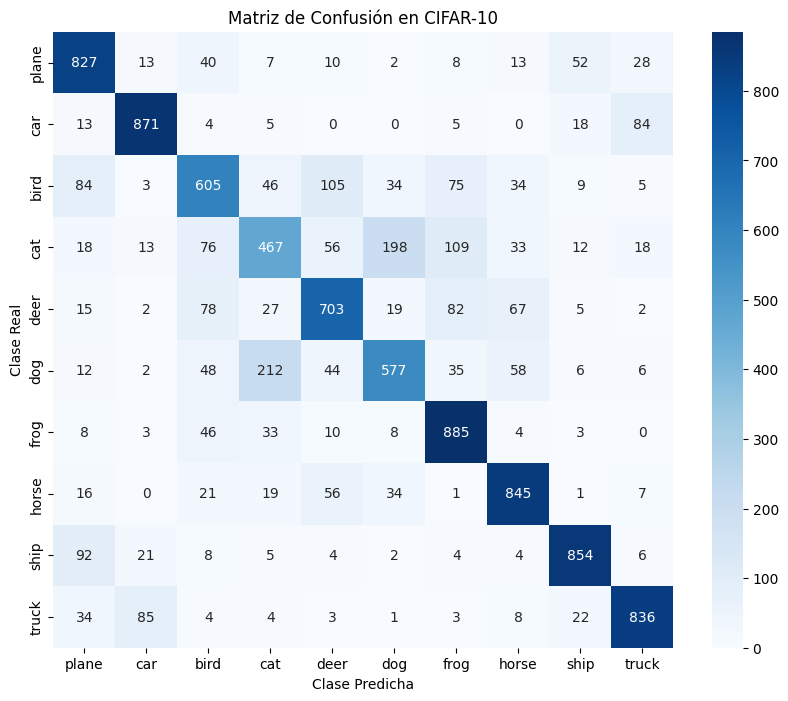

In [39]:
cm = confusion_matrix(all_labels_knn, all_preds_knn)

# 3. Dibujamos la matriz
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión en CIFAR-10')
plt.show()

### 🔍 Visualización de features

#### 🧩 Feature Maps

##### Backbone Congelado

In [40]:
classifier_lp.eval()

images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

images_batch = images_batch[:5, :, :, :]

with torch.no_grad():
    # Extraer features de la PRIMERA capa (índice 0 es Conv1, índice 1 es ReLU)
    # Pasamos solo por las primeras 2 capas del bloque
    features_conv1 = classifier_lp.encoder.feature_extractor[:2](images_batch)

    # Extraer features de la SEGUNDA capa (índice 3 es Conv2, índice 4 es ReLU)
    # Pasamos por las primeras 5 capas del bloque
    features_conv2 = classifier_lp.encoder.feature_extractor[:5](images_batch)


images_np = images_batch.cpu().numpy()
feat1_np = features_conv1.cpu().numpy() # Forma: (32, 6, 28, 28)
feat2_np = features_conv2.cpu().numpy() # Forma: (32, 16, 10, 10)

feat1_np.shape, feat2_np.shape

((5, 32, 32, 32), (5, 64, 16, 16))

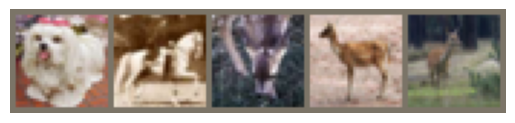

Canal 0


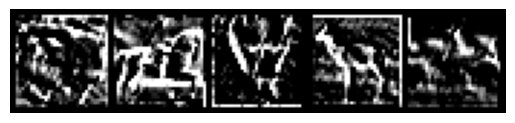

Canal 1


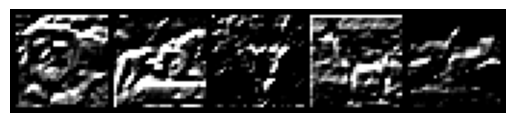

Canal 2


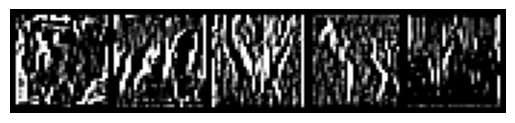

Canal 3


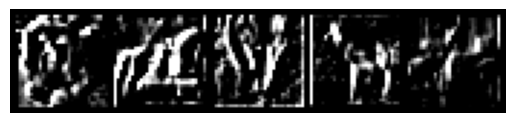

Canal 4


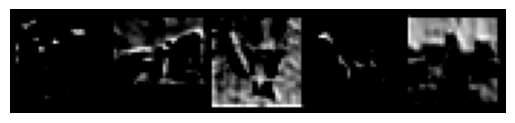

Canal 5


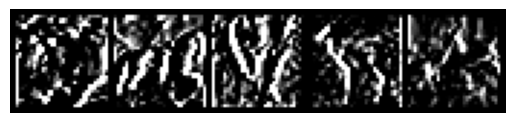

Canal 0


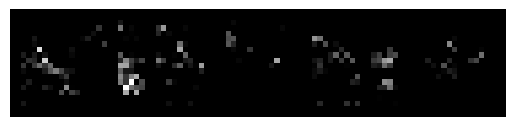

Canal 1


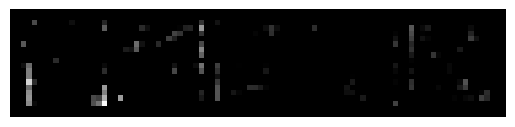

Canal 2


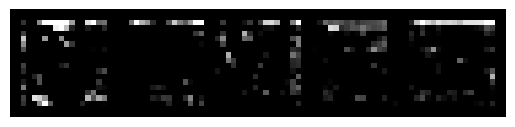

Canal 3


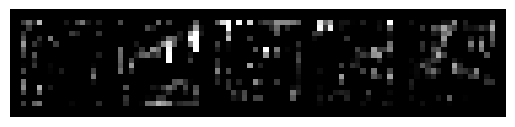

Canal 4


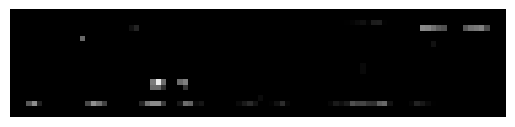

Canal 5


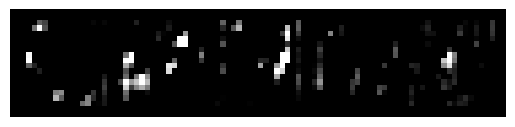

Canal 6


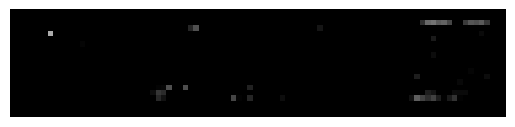

Canal 7


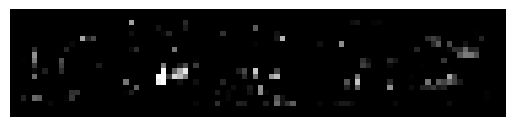

Canal 8


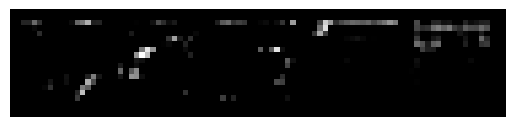

Canal 9


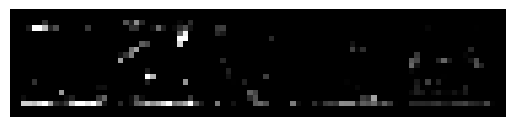

Canal 10


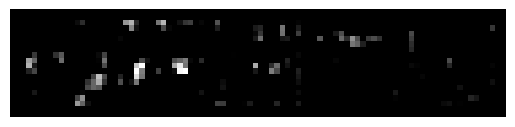

Canal 11


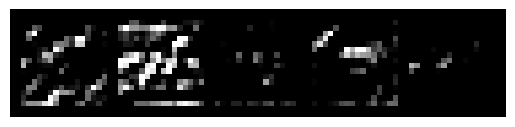

Canal 12


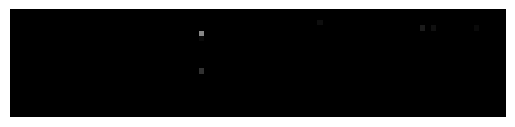

Canal 13


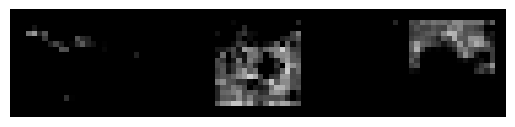

Canal 14


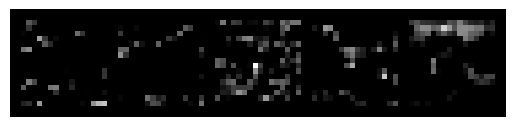

Canal 15


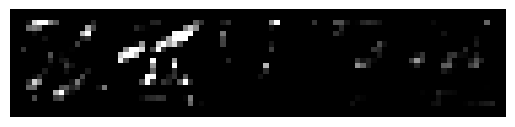

In [41]:
show_batch(
    torchvision.utils.make_grid(images_batch.to('cpu')),
)

for i in range(0, 6):
  print(f"Canal {i}")
  show_features(features_conv1, filter_index=i)

for i in range(0, 16):
  print(f"Canal {i}")
  show_features(features_conv2, filter_index=i)

##### Fine-tuning

In [42]:
classifier_ft.eval()

images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

images_batch = images_batch[:5, :, :, :]

with torch.no_grad():
    # Extraer features de la PRIMERA capa (índice 0 es Conv1, índice 1 es ReLU)
    # Pasamos solo por las primeras 2 capas del bloque
    features_conv1 = classifier_ft.encoder.feature_extractor[:2](images_batch)

    # Extraer features de la SEGUNDA capa (índice 3 es Conv2, índice 4 es ReLU)
    # Pasamos por las primeras 5 capas del bloque
    features_conv2 = classifier_ft.encoder.feature_extractor[:5](images_batch)


images_np = images_batch.cpu().numpy()
feat1_np = features_conv1.cpu().numpy() # Forma: (32, 6, 28, 28)
feat2_np = features_conv2.cpu().numpy() # Forma: (32, 16, 10, 10)

feat1_np.shape, feat2_np.shape

((5, 32, 32, 32), (5, 64, 16, 16))

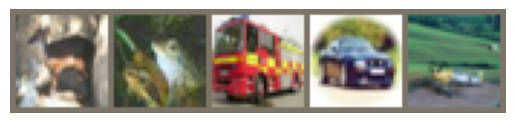

Canal 0


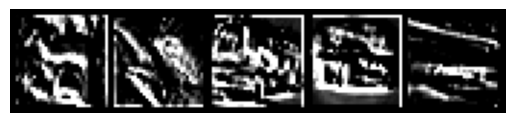

Canal 1


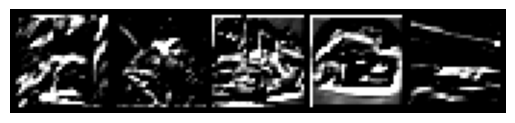

Canal 2


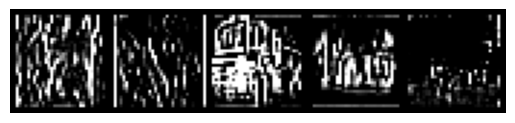

Canal 3


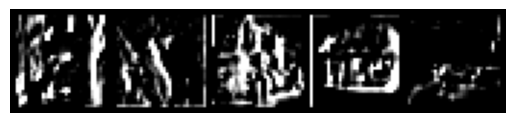

Canal 4


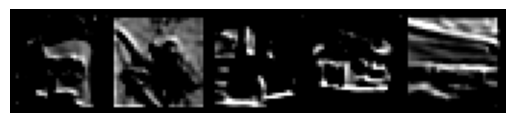

Canal 5


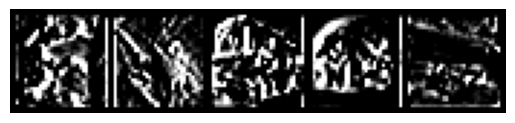

Canal 0


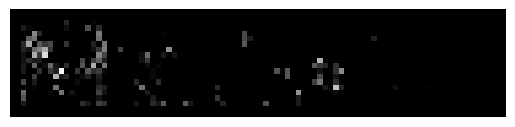

Canal 1


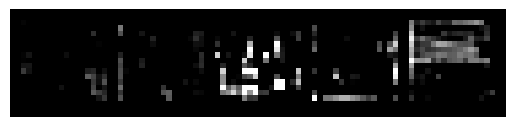

Canal 2


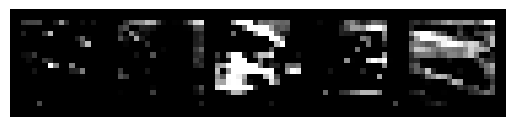

Canal 3


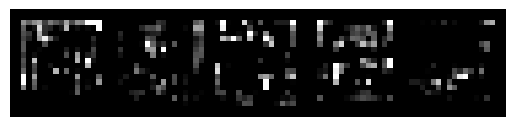

Canal 4


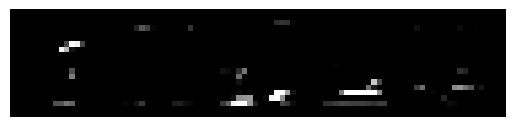

Canal 5


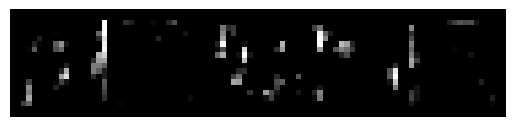

Canal 6


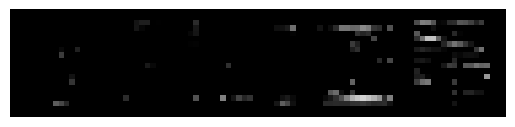

Canal 7


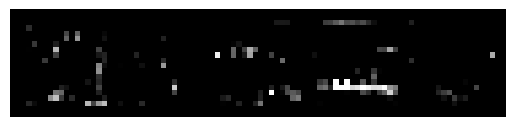

Canal 8


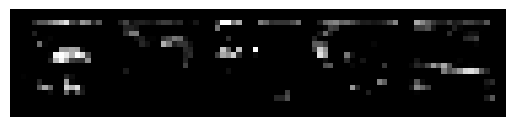

Canal 9


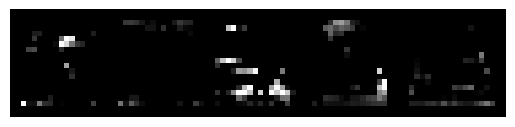

Canal 10


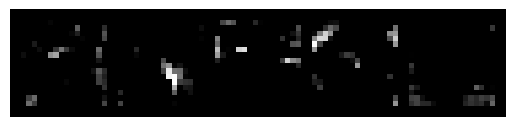

Canal 11


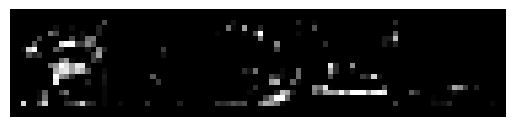

Canal 12


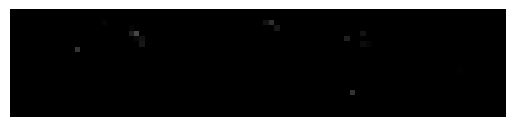

Canal 13


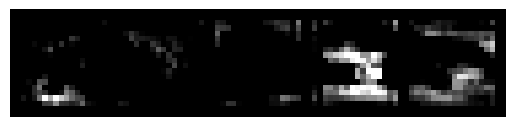

Canal 14


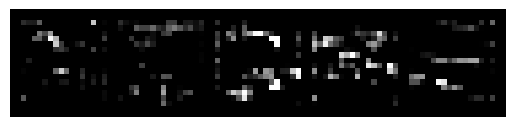

Canal 15


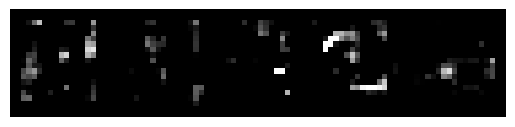

In [43]:
show_batch(
    torchvision.utils.make_grid(images_batch.to('cpu')),
)

for i in range(0, 6):
  print(f"Canal {i}")
  show_features(features_conv1, filter_index=i)

for i in range(0, 16):
  print(f"Canal {i}")
  show_features(features_conv2, filter_index=i)

#### 🧩 Proyección del espacio latente

##### Backbone Congelado

In [44]:
classifier_lp.eval()

all_features = []
all_labels = []

# 1. Extraemos representaciones latentes (antes de la capa final)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # CNN
        x = classifier_lp.encoder(images)

        # Guardamos
        all_features.append(x.cpu().numpy())
        all_labels.append(labels.numpy())

# Concatenamos todo en un solo array gigante
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_features.shape, all_labels.shape

((10000, 256), (10000,))

###### 🧩 3D

In [45]:
umap_embeddings = umap.UMAP(n_components=3).fit_transform(all_features)
umap_embeddings.shape

(10000, 3)

In [46]:
plot_latent_space_3d(
    umap_embeddings,
    all_labels,
    classes
)

###### 🧩 2d

In [47]:
umap_embeddings_2d = umap.UMAP(n_components=2).fit_transform(all_features)
umap_embeddings_2d.shape

(10000, 2)

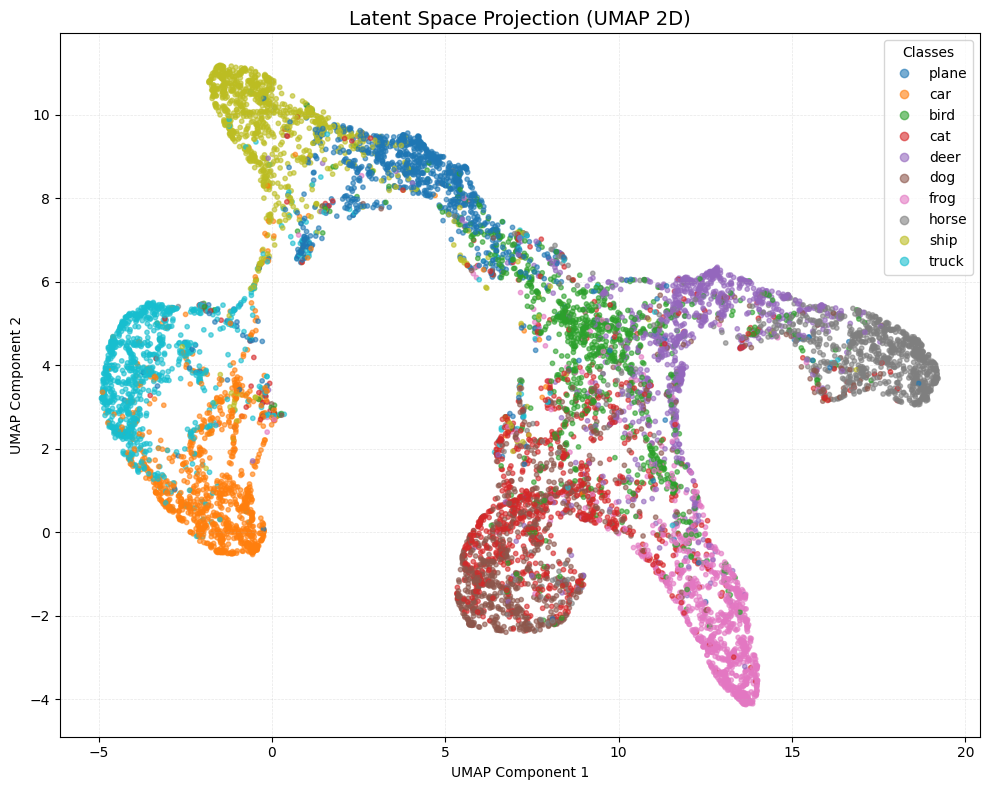

In [48]:
plot_latent_space_2d(
    umap_embeddings_2d,
    all_labels,
    classes
)

##### Fine-tuning

In [49]:
classifier_ft.eval()

all_features = []
all_labels = []

# 1. Extraemos representaciones latentes (antes de la capa final)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # CNN
        x = classifier_ft.encoder(images)

        # Guardamos
        all_features.append(x.cpu().numpy())
        all_labels.append(labels.numpy())

# Concatenamos todo en un solo array gigante
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_features.shape, all_labels.shape

((10000, 256), (10000,))

###### 🧩 3d

In [50]:
umap_embeddings = umap.UMAP(n_components=3).fit_transform(all_features)
umap_embeddings.shape

(10000, 3)

In [51]:
plot_latent_space_3d(
    umap_embeddings,
    all_labels,
    classes
)

###### 🧩 2d

In [52]:
umap_embeddings_2d = umap.UMAP(n_components=2).fit_transform(all_features)
umap_embeddings_2d.shape

(10000, 2)

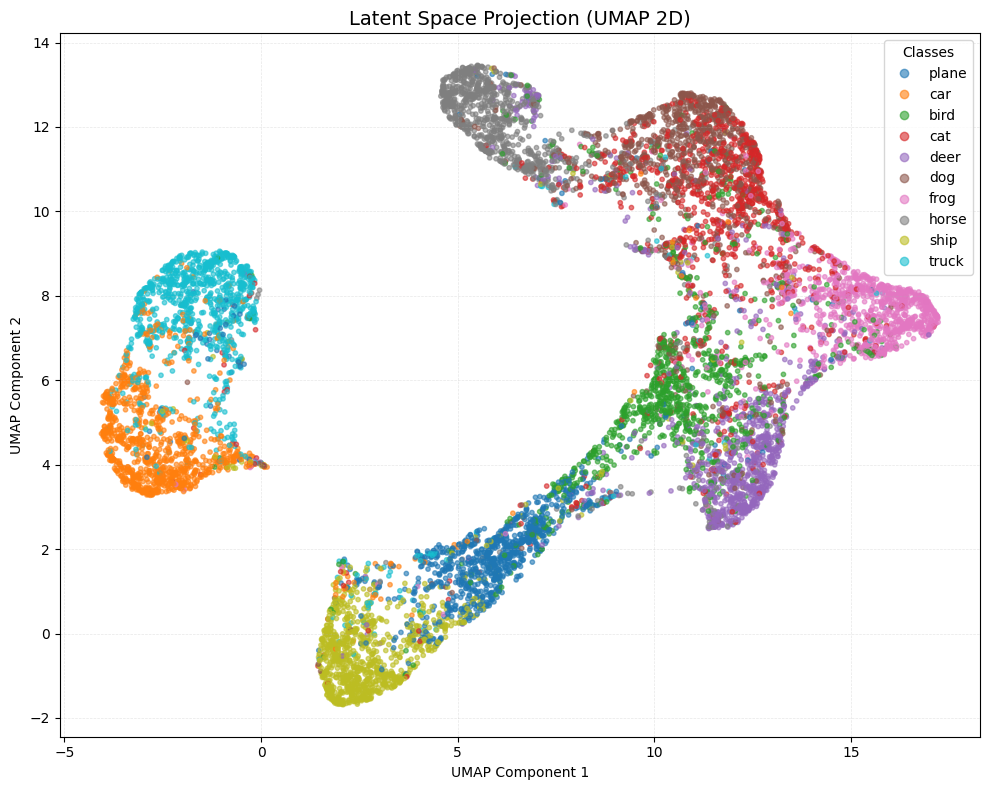

In [53]:
plot_latent_space_2d(
    umap_embeddings_2d,
    all_labels,
    classes
)